In [1]:
# Importing necessary libraries

import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import models, transforms
from PIL import Image


In [2]:
# getting the train and test data

train_df = pd.read_csv('C:\\IDL_project\\final_train_data.csv')
test_df = pd.read_csv('C:\\IDL_project\\final_test_data.csv')

test_df.shape

(2003, 2)

In [3]:
# Removing the augmentations added as they overfitted the model

train_df = train_df[~train_df['ImagePath'].str.endswith(('aug.jpg', '_aug2.jpg', '_aug1.jpg', 'aug3.jpg', 'aug4.jpg'))]
train_df.shape

(8012, 2)

In [4]:
combined_df = pd.concat([train_df, test_df], ignore_index=True)
combined_df.shape

(10015, 2)

In [5]:
# Combining another dataset with malignant images as original dataset was too imbalanced

import os
from matplotlib.pylab import shuffle
import pandas as pd
malignant_dir = 'C:\\IDL_project\\Dataset\\Malignant'

image_paths = [os.path.join(malignant_dir, fname) for fname in os.listdir(malignant_dir)
               if fname.lower().endswith(('.jpg'))]

malignant_df = pd.DataFrame({
    'ImagePath': image_paths,
    'BinaryType': 1
})

combined_df = pd.concat([combined_df, malignant_df], ignore_index=True)

combined_df = combined_df.sample(frac=1, random_state=None).reset_index(drop=True)
combined_df.shape

(16605, 2)

In [6]:
combined_df.value_counts('BinaryType')

BinaryType
1    8544
0    8061
Name: count, dtype: int64

In [7]:
from sklearn.model_selection import train_test_split

# Check class distribution
print(combined_df['BinaryType'].value_counts())

# Stratified split: 80% train, 20% test
train_df, test_df = train_test_split(
    combined_df,
    test_size=0.2,
    stratify=combined_df['BinaryType'],
    random_state=42
)

BinaryType
1    8544
0    8061
Name: count, dtype: int64


In [8]:
print(train_df['BinaryType'].value_counts())
print(test_df['BinaryType'].value_counts())

BinaryType
1    6835
0    6449
Name: count, dtype: int64
BinaryType
1    1709
0    1612
Name: count, dtype: int64


In [9]:
# Applying random augmentations to the training data for better generalization
# Also resizing the images to a standard size

import torchvision.transforms as transforms
import torch
transform_train = transforms.Compose([
    transforms.Resize((256, 256)),                # Resize to slightly larger
    transforms.RandomCrop(224),                   # Random crop to target size
    transforms.RandomHorizontalFlip(p=0.5),       # Flip images for invariance
    transforms.RandomRotation(degrees=15),        # Small rotations
    transforms.ColorJitter(                       # Change brightness/contrast
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),               # No crop or flip for val/test
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

In [10]:
# # # Load images and apply transformations (No Dataset class needed)
# train_images = torch.stack([transform_train(Image.open(p).convert('RGB')) for p in train_df['ImagePath'].tolist()])
# test_images = torch.stack([transform_val(Image.open(p).convert('RGB')) for p in test_df['ImagePath'].tolist()])



In [11]:
# torch.save(train_images, 'train_images.pt')
# torch.save(test_images, 'test_images.pt')

In [9]:
# Comverting the dataset into torch loadable tensors

train_images = torch.load('train_images.pt')
test_images = torch.load('test_images.pt')

# Convert labels to tensors
train_labels = torch.tensor(train_df['BinaryType'].values, dtype=torch.long)
test_labels = torch.tensor(test_df['BinaryType'].values, dtype=torch.long)

# Create TensorDatasets
train_dataset = TensorDataset(train_images, train_labels)
test_dataset = TensorDataset(test_images, test_labels)

# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

del train_images
del test_images
del train_dataset
del test_dataset
torch.cuda.empty_cache()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CNN(nn.Module):
    def __init__(self, num_classes=2, input_channels=3):
        super(CNN, self).__init__()
        
        # Layer 1: Initial convolution with larger receptive field
        # Input: 224x224x3, Output: 112x112x64
        self.conv1 = nn.Conv2d(input_channels, 64, kernel_size=7, stride=2, padding=3)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu1 = nn.ReLU(inplace=True)
        self.pool1 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        # After pool1: 56x56x64
        
        # Layer 2: First standard convolutional layer
        # Input: 56x56x64, Output: 56x56x128
        self.conv2 = nn.Conv2d(64, 128, kernel_size=5, stride=1, padding=2)
        self.bn2 = nn.BatchNorm2d(128)
        self.relu2 = nn.ReLU(inplace=True)
        self.pool2 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        # After pool2: 28x28x128
        
        # Layer 3: Second convolutional layer
        # Input: 28x28x128, Output: 28x28x256
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(256)
        self.relu3 = nn.ReLU(inplace=True)
        self.pool3 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        # After pool3: 14x14x256
        
        # Layer 4: Third convolutional layer
        # Input: 14x14x256, Output: 14x14x384
        self.conv4 = nn.Conv2d(256, 384, kernel_size=3, stride=1, padding=1)
        self.bn4 = nn.BatchNorm2d(384)
        self.relu4 = nn.ReLU(inplace=True)
        
        # Layer 5: Fourth convolutional layer
        # Input: 14x14x384, Output: 14x14x512
        self.conv5 = nn.Conv2d(384, 512, kernel_size=3, stride=1, padding=1)
        self.bn5 = nn.BatchNorm2d(512)
        self.relu5 = nn.ReLU(inplace=True)
        self.pool5 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        # After pool5: 7x7x512
        
        # Layer 6: Fifth convolutional layer
        # Input: 7x7x512, Output: 7x7x512
        self.conv6 = nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1)
        self.bn6 = nn.BatchNorm2d(512)
        self.relu6 = nn.ReLU(inplace=True)
        
        # Layer 7: Sixth convolutional layer, final conv layer
        # Input: 7x7x512, Output: 7x7x512
        self.conv7 = nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1)
        self.bn7 = nn.BatchNorm2d(512)
        self.relu7 = nn.ReLU(inplace=True)
        
        # Flatten: 7x7x512 = 25088
        self.flatten_size = 7 * 7 * 512
        
        # Layer 8: First fully connected layer
        self.fc1 = nn.Linear(self.flatten_size, 4096)
        self.relu_fc1 = nn.ReLU(inplace=True)
        self.dropout1 = nn.Dropout(0.5)
        
        # Layer 9: Second fully connected layer
        self.fc2 = nn.Linear(4096, 1024)
        self.relu_fc2 = nn.ReLU(inplace=True)
        self.dropout2 = nn.Dropout(0.5)
        
        # Layer 10: Final classification layer
        self.fc3 = nn.Linear(1024, num_classes)
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.pool1(x)
        
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.pool2(x)
        
        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu3(x)
        x = self.pool3(x)
        
        x = self.conv4(x)
        x = self.bn4(x)
        x = self.relu4(x)
        
        x = self.conv5(x)
        x = self.bn5(x)
        x = self.relu5(x)
        x = self.pool5(x)
        
        x = self.conv6(x)
        x = self.bn6(x)
        x = self.relu6(x)
        
        x = self.conv7(x)
        x = self.bn7(x)
        x = self.relu7(x)

        x = torch.flatten(x, 1)

        x = self.fc1(x)
        x = self.relu_fc1(x)
        x = self.dropout1(x)
        
        x = self.fc2(x)
        x = self.relu_fc2(x)
        x = self.dropout2(x)
        
        x = self.fc3(x)
        
        return x

In [14]:
# Using GPU for faster training

model = CNN().to("cuda")

In [15]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import torch

labels = train_df['BinaryType'].values  # Should be 0 and 1
class_weights = compute_class_weight(class_weight='balanced',
                                     classes=np.unique(labels),
                                     y=labels)

alpha = 1  # Between 0 (no balancing) and 1 (fully balanced)
soft_weights = (1 - alpha) * np.ones_like(class_weights) + alpha * class_weights

class_weights_tensor = torch.tensor(soft_weights, dtype=torch.float).to("cuda")
print(class_weights_tensor)

tensor([1.0299, 0.9718], device='cuda:0')


In [16]:
# Defining the training values such as
# Learning rate, which optimizer to use, etc...

criterion = criterion = torch.nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.2)
optimizer = optim.AdamW(model.parameters(), lr=0.00005, weight_decay=0.0001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)

In [17]:
# The actual training loop

from tqdm import tqdm
import torch

# Lists to save metrics
train_losses, test_losses = [], []
train_accuracies, test_accuracies = [], []
best_acc = 0.0

num_epochs = 20

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")

    # ---------- TRAIN ----------
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in tqdm(train_loader, desc="Training"):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()

    avg_train_loss = running_loss / len(train_loader.dataset)
    train_acc = correct / len(train_loader.dataset)

    train_losses.append(avg_train_loss)
    train_accuracies.append(train_acc)

    # ---------- EVAL ----------
    model.eval()
    test_loss, test_correct = 0.0, 0

    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc="Testing"):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            test_loss += loss.item() * inputs.size(0)
            test_correct += (outputs.argmax(1) == labels).sum().item()

    avg_test_loss = test_loss / len(test_loader.dataset)
    test_acc = test_correct / len(test_loader.dataset)
    scheduler.step(test_loss)

    test_losses.append(avg_test_loss)
    test_accuracies.append(test_acc)

    # ---------- LOG ----------
    print(f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f" Test Loss: {avg_test_loss:.4f} |  Test Acc: {test_acc:.4f}")


    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), f"C:\\IDL_project\\BestModel\\BestModel10\\best_model.pt")
        print(f"Saved new best model with Test Acc: {test_acc:.4f}")



Epoch 1/20


Testing: 100%|██████████| 104/104 [00:01<00:00, 52.32it/s]


Train Loss: 0.6136 | Train Acc: 0.7101
 Test Loss: 0.5489 |  Test Acc: 0.7706
Saved new best model with Test Acc: 0.7706

Epoch 2/20


Testing: 100%|██████████| 104/104 [00:01<00:00, 52.03it/s]


Train Loss: 0.5446 | Train Acc: 0.7944
 Test Loss: 0.5461 |  Test Acc: 0.7841
Saved new best model with Test Acc: 0.7841

Epoch 3/20


...

Train Loss: 0.3525 | Train Acc: 0.9828
 Test Loss: 0.5284 |  Test Acc: 0.8296

Epoch 19/20


Testing: 100%|██████████| 104/104 [00:01<00:00, 52.11it/s]


Train Loss: 0.3486 | Train Acc: 0.9848
 Test Loss: 0.4998 |  Test Acc: 0.8606

Epoch 20/20


Testing: 100%|██████████| 104/104 [00:01<00:00, 52.41it/s]

Train Loss: 0.3482 | Train Acc: 0.9847
 Test Loss: 0.5116 |  Test Acc: 0.8458


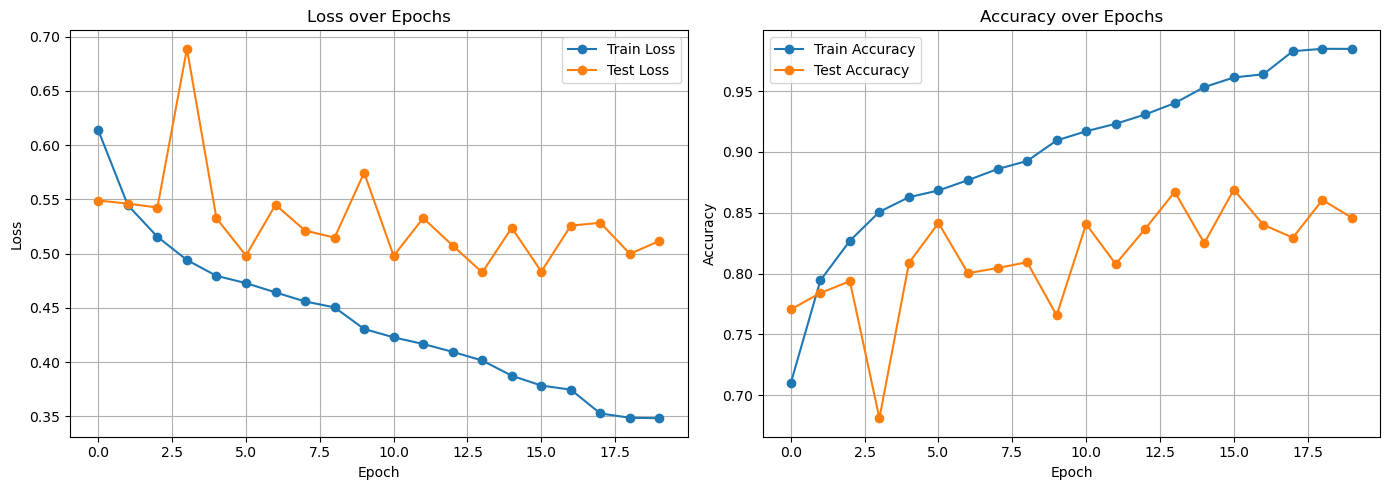

In [18]:
import matplotlib.pyplot as plt

# Plotting training and testing loss
plt.figure(figsize=(14, 5))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(test_losses, label='Test Loss', marker='o')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy', marker='o')
plt.plot(test_accuracies, label='Test Accuracy', marker='o')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


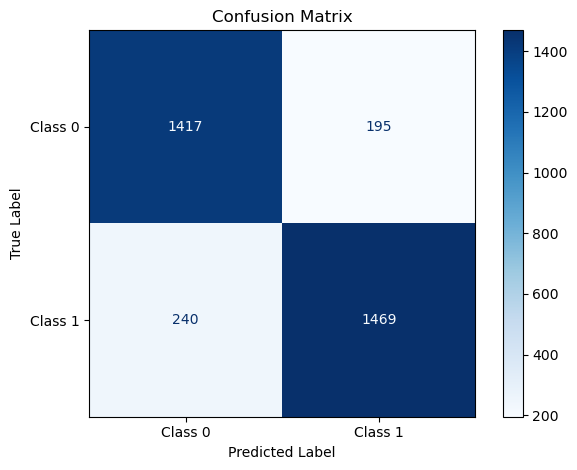

In [12]:
import torch
import torchvision.models as models
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Recreate the model architecture
from torchvision.models import resnet18

# Create the model
model = CNN()

# Load the saved state_dict
model.load_state_dict(torch.load('C:\\IDL_project\\BestModel\\BestModel10\\best_model.pt'))

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

# Assuming test_loader is already defined
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        preds = outputs.argmax(1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Compute and display confusion matrix
cm = confusion_matrix(all_labels, all_preds)
class_names = ['Class 0', 'Class 1']

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', values_format='d')

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [13]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)

# Accuracy
acc = accuracy_score(all_labels, all_preds)
print(f"Accuracy: {acc:.4f}")

precision = precision_score(all_labels, all_preds)
print(f"Precision: {precision:.4f}")

recall = recall_score(all_labels, all_preds)
print(f"Recall: {recall:.4f}")

# F1 Score
f1 = f1_score(all_labels, all_preds)
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.8690
Precision: 0.8828
Recall: 0.8596
F1 Score: 0.8710


AUC: 0.9265


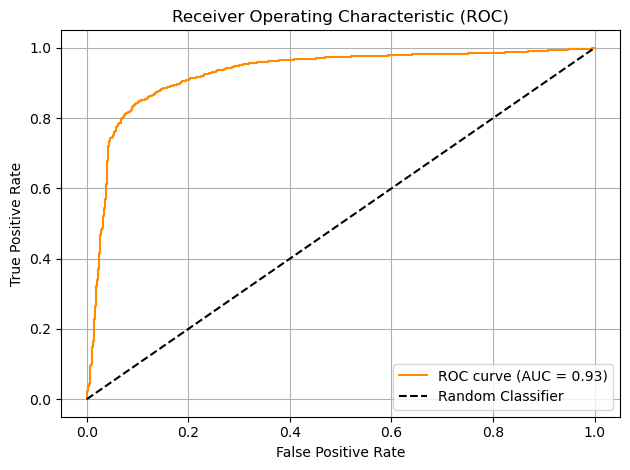

In [14]:
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score, roc_curve

# Step 4: Get probabilities and labels
all_probs = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)

        # Softmax over class dimension, get probability for class 1
        probs = F.softmax(outputs, dim=1)[:, 1]
        
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Step 5: Compute AUC
auc = roc_auc_score(all_labels, all_probs)
print(f"AUC: {auc:.4f}")

# Step 6: Plot ROC curve
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.2f})", color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()